# RPG Tournament

RPG Tournament will be spread across 8 sepeate code files. 1,5,6,7 will be in Jupyter Lab Notebooks here in this notebook. 3 and 4 will be seperate python files and you'll execute 4 when you want to run your battler.

• part1_fighters - This will create the fighters for the project

• part2_load_fighters - This will ensure your fighters are loaded from the .csv.

• part3_setup.py - This will setup the core systems for the battler. You won't run this program as it will only be referenced in the next file.

• part4_battle.py - This will be the main battle function program that will reference part 3. You will run this by double-clicking the .py file to run it.

• part5_stats_summary - Resuming in Jupyter-notebook, this shows a summary of the stats based on the battle data.

• part6_ai_predict - This will use the data from the summary to train an AI model to predict the winner of future battles.

• part7_mass_simulator - This will allow you to run many battles very quickly for gathering data.

• part8_bracket - This will allow you to run many battles in a tournament style

### part1_fighters: The first program you write will create all the fighters for the project.

In [12]:
# part1_fighters.py
import os
import pandas as pd

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

CSV_PATH = os.path.join(SCRIPT_DIR, "fighters.csv")
SPRITE_DIR = os.path.join(SCRIPT_DIR, "sprites")
os.makedirs(SPRITE_DIR, exist_ok=True)

CLASS_MODIFIERS = {
    "Always Wins": {"health": +0, "strength": +0, "defense": -0, "speed": 50, "stamina": +0, "evasion": 0.125, "stamina_regen": 1000, "stamina_light": 200, "stamina_heavy": 750},
    "Numero Uno": {"health": -0, "strength": +0, "defense": +0, "speed": 35, "stamina": +0, "evasion": 0.025, "stamina_regen": 400, "stamina_light": 200, "stamina_heavy": 750},
    "Numero Dos": {"health": +0, "strength": + 0, "defense": + 0, "speed": 75, "stamina": -0, "evasion": 0.2, "stamina_regen": 1300, "stamina_light": 200, "stamina_heavy": 750},
    "Numero Tres": {"health": +0, "strength": +0, "defense": -0, "speed": 50, "stamina": +0, "evasion": 0.085, "stamina_regen": 950, "stamina_light": 200, "stamina_heavy": 750}
}

def apply_class_modifiers(fighter):
    class_name = fighter.get("class","")
    modifiers = CLASS_MODIFIERS.get(class_name, {})
    for stat_name, class_value in modifiers.items():
        special_stats = ("crit_chance", "crit_bonus", "attacks")
        if stat_name in special_stats:
            fighter[stat_name] = class_value
        else:
            base_value = fighter.get(stat_name, 0)
            new_value = base_value + class_value
            fighter[stat_name] = new_value


FIGHTERS = [
    {
        "name": "Los Buddyachos",
        "class": "Always Wins",
        "health": 999999999999,
        "strength": 999999999999,
        "defense": 999999999999,
        "stamina": 999999999999,
        "critchance": 0.99,
        "critmult": 999.9,
        "sprite": "buddyachos.png",
        "sprite_scale": 2.0,
    },
    {
        "name": "Banana Brute",
        "class": "Numero Uno",
        "health": 20000000,
        "strength": 3250000,
        "defense": 100000,
        "stamina": 6700,
        "critchance": 0.2,
        "critmult": 8.5,
        "sprite": "bananabrute.png",
        "sprite_scale": 5.0,
    },
    {
        "name": "Reze",
        "class": "Numero Dos",
        "health": 18550000,
        "strength": 2000000,
        "defense": 290000,
        "stamina": 20000,
        "critchance": 0.55,
        "critmult": 10.0,
        "sprite": "reze.png",
        "sprite_scale": 1.5,
    },
    {
        "name": "Mr. I Hate Plants All Plants Should Die",
        "class": "Numero Tres",
        "health": 50000000,
        "strength": 1400000,
        "defense": 310000,
        "stamina": 10000,
        "critchance": 0.05,
        "critmult": 99.9,
        "sprite": "edgar.png",
        "sprite_scale": 5.0,
    },
    {
        "name": "Don Frye²",
        "class": "Numero Dos",
        "health": 5000000,
        "strength": 3000000,
        "defense": 10000,
        "stamina": 10000,
        "critchance": 0.25,
        "critmult": 9999.9,
        "sprite": "thragg.webp",
        "sprite_scale": 2.5,
    },
    {
        "name": "Big Boom",
        "class": "Numero Dos",
        "health": 1,
        "strength": 999999999999,
        "defense": 1,
        "stamina": 10000,
        "critchance": 0.001,
        "critmult": 999999999999999999999999999999.9,
        "sprite": "hector.png",
        "sprite_scale": 2.0,
    },
    {
        "name": "Sunflower",
        "class": "Numero Tres",
        "health": 16767676.7,
        "strength": 1690000,
        "defense": 300000,
        "stamina": 100000000,
        "critchance": 0.85,
        "critmult": 50.0,
        "sprite": "sunflower.png",
        "sprite_scale": 2.0,
    },
]

fighters = [f.copy() for f in FIGHTERS]
for fighter in fighters:
    apply_class_modifiers(fighter)
    
df = pd.DataFrame(fighters)
df.to_csv(CSV_PATH, index=False)
print(f"Saved {len(fighters)} fighters to {CSV_PATH}")

Saved 7 fighters to C:\Users\Student\Desktop\SantiagoP\rpg_tournament\fighters.csv


### part2_Load_fighters.py:

In [4]:
# #part2_load_fighters.py
# import os
# import pandas as pd

# try:
#     SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
# except NameError:
#     SCRIPT_DIR = os.getcwd()

# CSV_PATH = os.path.join(SCRIPT_DIR, "fighters.csv")
# SPRITE_DIR = os.path.join(SCRIPT_DIR, "sprites")

# class Fighter:
#     def __init__(self, row: dict):
#         self._base_row = row.copy()
#         self.name = row.get("name", "Unknown")
#         self.cls = row.get("class", "")
#         self.health = int(row.get("health", 0))
#         self.max_health = self.health
#         self.strength = int(row.get("strength", 0))
#         self.defense = int(row.get("defense", 0))
#         self.crit_chance = int(row.get("crit_chance", 0))
#         self.crit_bonus = int(row.get("crit_bonus", 0))
#         self.attacks = int(row.get("attacks", 0))
        
#         self.sprite = (row.get("sprite") or "").strip()
#         self.sprite_scale = float(row.get("sprite_scale", 1.0))


#     def reset_for_battle(self):
#         self.health = self.max_health


#     def is_alive(self) -> bool:
#         return self.health > 0


#     def clone_for_battle(self) -> "Fighter":
#         return Fighter(self._base_row)


# def load_fighters(csv_path=CSV_PATH):
#     rows = pd.read_csv(csv_path).to_dict("records")
#     return [Fighter(row) for row in rows]

#     if __name__ == "__main__":
#         fighters = load_righters()
#         print(f"Loaded {len(fighters)} Fighters From {CSV_PATH}\n")
#         header = f"{'Idx':>3} {'Name':12} {'Class':10} {'HP':>4}{'STR':>4}{'DEF':>4}{'CRIT CH':>4}{'CRIT BNS':>4}"
#         print(header)
#         print("-" * len(header))
#         for i, f in enumerate(fighters, 1):
#             print(
#                 f"{i:3d}. {f.name[:12]:12} {f.cls[:10]:10}"
#                 f"{f.max_health:4d}, {f.strength:4d} {f.defense:4d}"
#                 f"{f.crit_chance:4d}, {f.crit_bonus:4d}"
#             )


#part2_load_fighters.py
import os
import pandas as pd

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

CSV_PATH = os.path.join(SCRIPT_DIR, "fighters.csv")
SPRITE_DIR = os.path.join(SCRIPT_DIR, "sprites")


# Fighter Class
class Fighter:

    def __init__(self, row: dict):

        self._base_row = row.copy()

        self.name = row.get("name", "Unknown")
        self.cls = row.get("class", "")

        self.health = int(row.get("health", 0))
        self.max_health = self.health
        self.strength = int(row.get("strength", 0))
        self.defense = int(row.get("defense", 0))
        self.speed = int(row.get("speed", 0))
        self.stamina = int(row.get("stamina", 0))
        self.current_stamina = self.stamina

        self.critchance = float(row.get("critchance", 0.0))
        self.critmult = float(row.get("critmult", 1.0))
        self.evasion = float(row.get("evasion", 0.0))

        self.stamina_regen = int(row.get("stamina_regen", 2))
        self.stamina_light = int(row.get("stamina_light", 8))
        self.stamina_heavy = int(row.get("stamina_heavy", 16))

        self.sprite = (row.get("sprite") or "").strip()
        self.sprite_scale = float(row.get("sprite_scale", 1.0))

    # Reset Stats Before A Battle
    def reset_for_battle(self):
        self.health = self.max_health
        self.current_stamina = self.stamina

    # Is Fighter Alive
    def is_alive(self) -> bool:
        return self.health > 0

    # New Fighter on New Battles
    def clone_for_battle(self) -> "Fighter":
        return Fighter(self._base_row)


# Load Fighters From csv:
def load_fighters(csv_path=CSV_PATH):
    rows = pd.read_csv(csv_path).to_dict("records")
    return [Fighter(row) for row in rows]


# Preview from csv.
if __name__ == "__main__":
    fighters = load_fighters()
    print(f"Loaded {len(fighters)} Fighters From {CSV_PATH}\n")

    header = f"{'Idx':>3}  {'Name':12} {'Class':10} {'HP':>4} {'STR':>4} {'DEF':>4} {'SPD':>4} {'EVA':>5} {'STA':>4}"
    print(header)
    print("-" * len(header))

    for i, f in enumerate(fighters, 1):
        print(
            f"{i:3d}. {f.name[:12]:12} {f.cls[:10]:10} "
            f"{f.max_health:4d} {f.strength:4d} {f.defense:4d} {f.speed:4d} "
            f"{f.evasion:5.2f} {f.stamina:4d}"
        )

Loaded 7 Fighters From C:\Users\Student\Desktop\SantiagoP\rpg_tournament\fighters.csv

Idx  Name         Class        HP  STR  DEF  SPD   EVA  STA
-----------------------------------------------------------
  1. Los Buddyach Always Win 999999999999 999999999999 999999999999   50  0.12 999999999999
  2. Banana Brute Numero Uno 20000000 3250000 100000   35  0.03 6700
  3. Reze         Numero Dos 18550000 2000000 290000   75  0.20 20000
  4. Mr. I Hate P Numero Tre 50000000 1400000 310000   50  0.09 10000
  5. Don Frye²    Numero Dos 5000000 3000000 10000   75  0.20 10000
  6. Big Boom     Numero Dos    1 999999999999    1   75  0.20 10000
  7. Sunflower    Numero Tre 6767676 1690000 300000   50  0.09 100000000


Next you will go through Parts 3 and 4 to create the setup and the battle program.

### part5_stats_summary.py:

The rest of the code will be programmed below.

Loaded move and result logs.

----1.Fighter Participation Summary -----


,Fighter,Total Moves
17,Tucker,7506
14,Scout,7503
11,Reze,3553
8,Mike Tyson,3316
0,Banana Brute,286
9,Monster Garou,271
4,Grimlock,209
3,Dr. Edgar Zomboss,72
16,Thragg,42
10,Mr. I Hate Plants All Plants Should Die,15


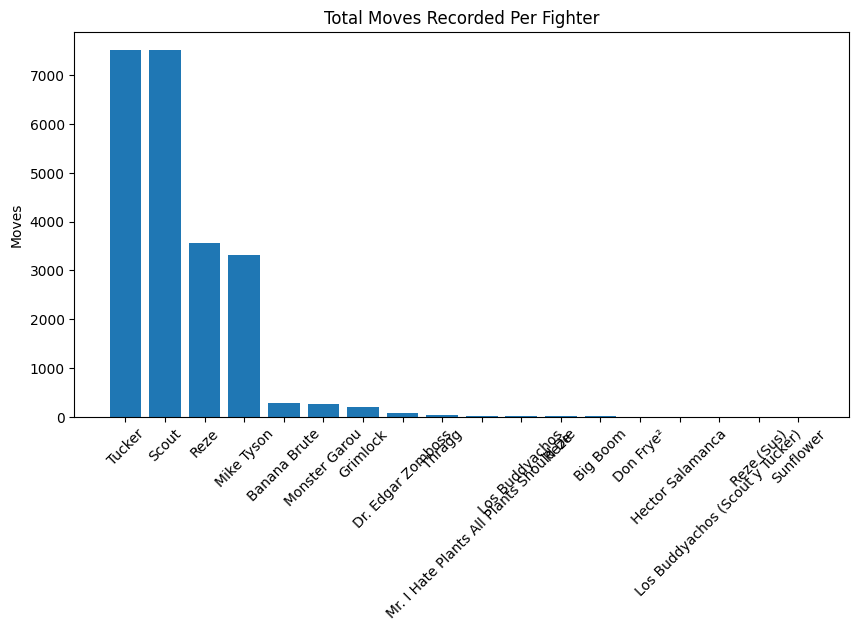


----2. Win / Loss Summary -----


,Fighter,Wins,Losses,Total Fights,Win Rate,Win Rate %
11,Reze,39,27,40,0.975000,97.5
0,Banana Brute,37,39,38,0.973684,97.4
4,Grimlock,22,12,23,0.956522,95.7
9,Monster Garou,20,24,21,0.952381,95.2
8,Mike Tyson,18,38,19,0.947368,94.7
6,Los Buddyachos,10,0,11,0.909091,90.9
15,Thragg,7,10,8,0.875000,87.5
2,Don Frye²,6,3,7,0.857143,85.7
17,Tucker,6,0,7,0.857143,85.7
12,Reze,5,1,6,0.833333,83.3


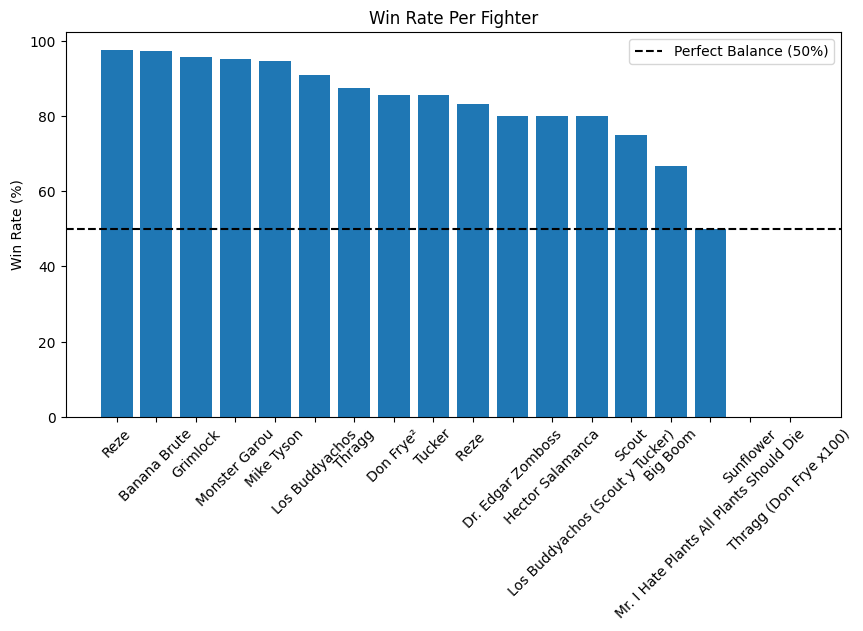


----3.Balance Score-----


In [5]:
# part5_stats_summary.py

# part5_stats_summary.py

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["figure.figsize"] = (10, 5)

SCRIPT_DIR = os.getcwd()
MOVES_PATH = os.path.join(SCRIPT_DIR, "battle_moves.csv")
RESULTS_PATH = os.path.join(SCRIPT_DIR, "results.csv")

# LOAD DATA

if not os.path.exists(MOVES_PATH):
    raise FileNotFoundError("battle_moves.csv not found. Run some battles first!")

df_moves = pd.read_csv(MOVES_PATH)
df_results = pd.read_csv(RESULTS_PATH) if os.path.exists(RESULTS_PATH) else None

print("Loaded move and result logs.")

print("\n----1.Fighter Participation Summary -----")

df_part = (
    df_moves
    .groupby("attacker")
    .size()
    .reset_index(name="Total Moves")
    .rename(columns={"attacker": "Fighter"})
    .sort_values("Total Moves", ascending=False)
)

display(df_part)
plt.bar(df_part["Fighter"], df_part["Total Moves"])
plt.title("Total Moves Recorded Per Fighter")

plt.ylabel("Moves")
plt.xticks(rotation=45)
plt.show()

print("\n----2. Win / Loss Summary -----")
wins = df_results["winner"].value_counts()
losses = df_results["loser"].value_counts()

fighters = sorted(set(wins.index).union(losses.index))
rows = []

for f in fighters:
    w = wins.get(f, 0)
    l = losses.get(f, 0)

    total = w + 1
    winrate = w / total if total > 0 else 0
    rows.append([f, w, l, total, winrate])

df_win = pd.DataFrame(
    rows,
    columns=["Fighter", "Wins", "Losses", "Total Fights", "Win Rate"]
)

df_win["Win Rate %"] = (df_win["Win Rate"] * 100).round(1)
df_win = df_win.sort_values("Win Rate", ascending=False)

display(df_win)

plt.bar(df_win["Fighter"], df_win["Win Rate %"])
plt.axhline(50, linestyle="--", color="black", label="Perfect Balance (50%)")
plt.ylabel("Win Rate (%)")

plt.title("Win Rate Per Fighter")
plt.xticks(rotation=45)
plt.legend()
plt.show()

print("\n----3.Balance Score-----")

df_win["Balance Score"] = abs(df_win["Win Rate"] - 0.5).round(2)

### part6_ai_predict.py:

In [6]:
# part6_ai_predict.py

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.ensemble import RandomForestClassifier
from IPython.display import clear_output
import ipywidgets as widgets


### part7_mass_simulator.py:

In [5]:
# part7_mass_simulator

import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from IPython.display import display, clear_output
import ipywidgets as widgets

from part2_load_fighters import load_fighters
from part4_battle import simulate_battle, save_results
from part3_setup import save_moves



pygame 2.6.1 (SDL 2.28.4, Python 3.10.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


### part8_bracket.py:

In [6]:
# part8_bracket.py

import os
import random
import pandas as pd
from IPython.display import display, clear_output
import ipywidgets as widgets

from part2_load_fighters import load_fighters
from part4_battle import simulate_battle, save_results
from part3_setup import save_moves

